## GUI

GUI is created for all the steps that has been performed earlier.


In [1]:
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import joblib
import os
import random
import threading
import traceback
from pathlib import Path
import tkinter as tk
from tkinter import filedialog, messagebox
import customtkinter as ctk
from PIL import Image, ImageTk


In [2]:
# Set dark theme options for modern UI look
ctk.set_appearance_mode("Dark")
ctk.set_default_color_theme("blue")


# 1. CORE PIPELINE CONTROLLER

class PalmBiometricEngine:
    def __init__(self, db_path):
        self.db_path = Path(db_path)
        self.initialized = False
        
        if not self.db_path.exists():
            print(f"Database path does not exist: {self.db_path}")
            return

        print("Loading template feature arrays database from disk...")
        db_package = joblib.load(str(self.db_path))
        self.db_embeddings = db_package["embeddings"]
        self.db_labels = np.array(db_package["labels"])
        self.db_handedness = np.array(db_package["handedness"])
        self.db_filepaths = np.array(db_package["filepaths"])
        print(f"Loaded {len(self.db_labels)} embeddings from registry.")
        
        print("Initializing MediaPipe Hand Tracking Engine...")
        self.mp_hands = mp.solutions.hands
        self.detector = self.mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.5)
        
        print("Initializing ResNet50 Feature Extractor Backbone...")
        from tensorflow.keras.applications.resnet50 import ResNet50
        from tensorflow.keras.models import Model
        
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
        self.feature_extractor = Model(inputs=base_model.input, outputs=pooling_layer)
        
        print("Warming up inference runtime features...")
        dummy_input = np.zeros((1, 224, 224, 3), dtype=np.float32)
        _ = self.feature_extractor.predict(dummy_input, verbose=0)
        
        self.initialized = True
        print("Continuous Verification Engine Online!")

    def extract_aligned_roi(self, img, config, landmarks):
        """Processes a single frame for localization and alignment during continuous video tracking."""
        h, w, _ = img.shape
        
        # Pull geometric coordinate points
        def get_pt(lm_idx): 
            return np.array([landmarks[lm_idx].x * w, landmarks[lm_idx].y * h], dtype="float32")

        p0, p5, p9, p17 = get_pt(0), get_pt(5), get_pt(9), get_pt(17)
        hand_label = "Right" if (p5[0]-p0[0])*(p17[1]-p0[1]) - (p5[1]-p0[1])*(p17[0]-p0[0]) > 0 else "Left"

        # Calculate a rigid vertical direction vector relative to the wrist position anchor point
        v_vertical = p9 - p0
        v_vertical_unit = v_vertical / np.linalg.norm(v_vertical)
        v_horizontal_unit = np.array([-v_vertical_unit[1], v_vertical_unit[0]], dtype="float32")
        
        # Geometrically scale bounding boxes uniformly to match training data
        palm_width = np.linalg.norm(p17 - p5)
        roi_center = p9 - (v_vertical_unit * (palm_width * config["roi_center_shift"]))
        half_size = (palm_width * config["roi_size_multiplier"]) / 2.0
        
        # Construct the four corners of your upright square matrix bounds
        local_top_left     = roi_center - (v_horizontal_unit * half_size) + (v_vertical_unit * half_size)
        local_top_right    = roi_center + (v_horizontal_unit * half_size) + (v_vertical_unit * half_size)
        local_bottom_right = roi_center + (v_horizontal_unit * half_size) - (v_vertical_unit * half_size)
        local_bottom_left  = roi_center - (v_horizontal_unit * half_size) - (v_vertical_unit * half_size)
        
        src_pts = np.array([local_top_left, local_top_right, local_bottom_right, local_bottom_left], dtype="float32")
        dst_pts = np.array([[0, 0], [224, 0], [224, 224], [0, 224]], dtype="float32")

        # Background segmentation masking rules
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillConvexPoly(mask, src_pts.astype(int), 255)
        img_no_bg = cv2.bitwise_and(img, img, mask=mask)
        
        # Warp perspective cleanly into a standardized 224x224 patch canvas frame
        M = cv2.getPerspectiveTransform(src_pts, dst_pts)
        roi_color = cv2.warpPerspective(img_no_bg, M, (224, 224))

        # Core Preprocessing Operations Block Sequence
        roi_gray = cv2.cvtColor(roi_color, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=config["clahe_clip_limit"], tileGridSize=config["clahe_grid_size"]).apply(roi_gray)
        blurred = cv2.medianBlur(clahe, int(config["median_blur_kernel"]))
        normalized = cv2.normalize(blurred, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

        # MFRAT High-Contrast Transformation Module Engine
        img_f = normalized.astype(np.float32)
        b_size = int(config["mfrat_block_size"])
        center = b_size // 2
        y_idx, x_idx = np.indices((b_size, b_size))
        x_idx, y_idx = x_idx - center, y_idx - center
        
        mfrat_energy_stack = np.zeros((224, 224, config["num_directions"]), dtype=np.float32)
        local_mean = cv2.boxFilter(img_f, -1, (b_size, b_size), borderType=cv2.BORDER_REFLECT)
        
        for d in range(config["num_directions"]):
            theta = (d * np.pi) / config["num_directions"]
            mask_line = np.abs(x_idx * np.cos(theta) + y_idx * np.sin(theta)) < 0.8
            line_sum = cv2.filter2D(img_f, -1, mask_line.astype(np.float32), borderType=cv2.BORDER_REFLECT)
            mfrat_energy_stack[:, :, d] = local_mean - (line_sum / np.sum(mask_line))

        final_energy = np.max(mfrat_energy_stack, axis=-1)
        final_energy[final_energy < (np.mean(final_energy) * config["mfrat_threshold_factor"])] = 0
        mfrat_final = cv2.normalize(cv2.GaussianBlur(final_energy, (5, 5), 0), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        return mfrat_final, hand_label, src_pts

    def get_embedding_vector(self, mfrat_roi):
        from tensorflow.keras.applications.resnet50 import preprocess_input
        img_3ch = cv2.cvtColor(mfrat_roi, cv2.COLOR_GRAY2RGB)
        img_batch = preprocess_input(np.expand_dims(img_3ch, axis=0).astype(np.float32))
        embedding = self.feature_extractor.predict(img_batch, verbose=0)[0]
        return embedding / np.linalg.norm(embedding)


# 2. ISOLATED AUGMENTATION UTILITIES

def safe_brightness(img, low=-30, high=30):
    value = random.randint(low, high)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    if value >= 0: v = cv2.add(v, value)
    else: v = cv2.subtract(v, abs(value))
    return cv2.cvtColor(cv2.merge((h, s, v)), cv2.COLOR_HSV2BGR)

def safe_rotate(img, angle_limit=5):
    angle = random.uniform(-angle_limit, angle_limit)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)


Loading template feature arrays database from disk...
Loaded 2288 embeddings from registry.
Initializing MediaPipe Hand Tracking Engine...
Initializing ResNet50 Feature Extractor Backbone...
Warming up inference runtime features...
Continuous Verification Engine Online!


c:\Users\singh\Users\singh\Desktop\Palm detection\venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\singh\AppData\Local\Temp\ipykernel_18704\3236164399.py:279: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self.fig.tight_layout(); self.canvas.draw()


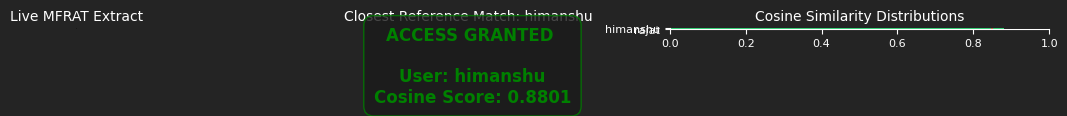

In [3]:


# 3. APPLICATION WINDOW GUI LAYOUT

class BiometricAppGUI(ctk.CTk):
    def __init__(self):
        super().__init__()
        
        self.title("Fully Automated Real-Time Palmprint Biometric Verification Console")
        self.geometry("1450x850")
        self.resizable(True, True)

        self.config = {
            "embeddings_db_path": r"C:\Users\singh\Users\singh\Desktop\Palm detection\ROI\05_palm_embeddings latest work.pkl",
            "enrollment_output_dir": r"C:\Users\singh\Users\singh\Desktop\Palm detection\ROI\01_Symmetric_Palm_ROI_Enrolled",
            "roi_size_multiplier": 1.1, "roi_center_shift": 0.5,
            "clahe_clip_limit": 7.0, "clahe_grid_size": (5, 5),
            "median_blur_kernel": 3, "num_directions": 12,
            "mfrat_block_size": 21, "mfrat_threshold_factor": 1.5,
            "cosine_threshold": 0.85, "aug_per_image": 99,
            "camera_id": 0
        }
        
        self.engine = None
        self.cap = None
        self.is_camera_running = False
        
        # Automated Verification Gate Stabilizers
        self.stable_frame_counter = 0
        self.required_stable_frames = 15  # Hand must stay in focus for ~0.5 seconds before auto-firing passes
        self.cooldown_counter = 0          # Prevents continuous duplicate matching spam loops
        self.current_landmarks = None
        
        self.create_ui_layout()
        self.after(200, self.try_initialize_engine)

    def try_initialize_engine(self):
        try:
            db_p = self.config["embeddings_db_path"]
            self.lbl_db_status.configure(text="Initializing Autonomous Engine Backbone...", text_color="orange")
            self.update()
            
            self.engine = PalmBiometricEngine(db_p)
            if self.engine.initialized:
                self.lbl_db_status.configure(text=f"Database Loaded: {Path(db_p).name} ({len(self.engine.db_labels)} profiles) ✅", text_color="green")
                self.start_live_video_stream()
            else:
                self.lbl_db_status.configure(text="Database File Error: Check Path / Run Step 7", text_color="red")
        except Exception as e:
            print(traceback.format_exc())
            messagebox.showerror("Initialization Error", f"Failed to initialize autonomous frameworks:\n{str(e)}")

    def create_ui_layout(self):
        self.sidebar_frame = ctk.CTkFrame(self, width=320, corner_radius=0)
        self.sidebar_frame.pack(side="left", fill="y", padx=0, pady=0)
        
        lbl_title = ctk.CTkLabel(self.sidebar_frame, text="AUTONOMOUS STREAM HUD", font=ctk.CTkFont(size=16, weight="bold"))
        lbl_title.pack(padx=20, pady=15)
        
        self.lbl_db_status = ctk.CTkLabel(self.sidebar_frame, text="Awaiting Registry Link...", font=ctk.CTkFont(size=12))
        self.lbl_db_status.pack(padx=20, pady=2)
        
        lbl_verify_section = ctk.CTkLabel(self.sidebar_frame, text="— AUTOMATION STATUS —", font=ctk.CTkFont(size=12, weight="bold"), text_color="gray60")
        lbl_verify_section.pack(padx=20, pady=(15, 5))

        self.lbl_auto_mode = ctk.CTkLabel(self.sidebar_frame, text="🔍 SCANNING FOR PALM SAMPLES", text_color="cyan", font=ctk.CTkFont(size=13, weight="bold"), fg_color="gray15", height=35, corner_radius=6)
        self.lbl_auto_mode.pack(padx=20, pady=10, fill="x")

        btn_browse_db = ctk.CTkButton(self.sidebar_frame, text="Link Embeddings Database (.pkl)", command=self.browse_database)
        btn_browse_db.pack(padx=20, pady=6, fill="x")
        
        enroll_box = ctk.CTkFrame(self.sidebar_frame, fg_color="gray15")
        enroll_box.pack(padx=15, pady=15, fill="both", expand=True)

        lbl_enroll_section = ctk.CTkLabel(enroll_box, text="DATABASE REGISTRY CONTROLS", font=ctk.CTkFont(size=12, weight="bold"), text_color="green")
        lbl_enroll_section.pack(padx=15, pady=(12, 8))

        ctk.CTkLabel(enroll_box, text="Target User ID String:", font=ctk.CTkFont(size=11)).pack(anchor="w", padx=15)
        self.ent_user_id = ctk.CTkEntry(enroll_box, placeholder_text="e.g., pranav_singh", font=ctk.CTkFont(size=11))
        self.ent_user_id.pack(padx=15, pady=(2, 8), fill="x")

        self.btn_commit_user = ctk.CTkButton(enroll_box, text="AUTO-CAPTURE & ENROLL USER", fg_color="green", text_color="white", font=ctk.CTkFont(size=12, weight="bold"), command=self.trigger_realtime_enrollment_pass)
        self.btn_commit_user.pack(padx=15, pady=6, fill="x")

        btn_remove_user = ctk.CTkButton(enroll_box, text="REMOVE USER FROM DATABASE", fg_color="#962d2d", hover_color="#bd3a3a", text_color="white", font=ctk.CTkFont(size=11, weight="bold"), command=self.execute_user_removal)
        btn_remove_user.pack(padx=15, pady=(6, 15), fill="x")

        self.main_content_frame = ctk.CTkFrame(self)
        self.main_content_frame.pack(side="right", fill="both", expand=True, padx=15, pady=15)
        
        self.video_display_frame = ctk.CTkFrame(self.main_content_frame, height=400, fg_color="black")
        self.video_display_frame.pack(fill="both", expand=True, padx=10, pady=5)
        
        self.video_label = tk.Label(self.video_display_frame, bg="black")
        self.video_label.pack(fill="both", expand=True)
        
        self.plot_frame = ctk.CTkFrame(self.main_content_frame, height=320, fg_color="gray15")
        self.plot_frame.pack(fill="x", side="bottom", padx=10, pady=5)
        
        self.fig, self.axs = plt.subplots(1, 3, figsize=(14, 3.2))
        self.fig.patch.set_facecolor('#242424')
        for ax in self.axs:
            ax.set_facecolor('#1a1a1a')
            ax.axis('off')
        
        self.canvas = FigureCanvasTkAgg(self.fig, master=self.plot_frame)
        self.canvas.get_tk_widget().pack(fill="both", expand=True)

    def browse_database(self):
        file = filedialog.askopenfilename(filetypes=[("Pickle Files", "*.pkl")])
        if file:
            self.config["embeddings_db_path"] = file
            self.try_initialize_engine()

   
    # AUTOMATED VIDEO STREAM STREAM CONTROLLER
   
    def start_live_video_stream(self):
        self.cap = cv2.VideoCapture(int(self.config["camera_id"]))
        if not self.cap.isOpened():
            messagebox.showerror("Camera Fault", "Unable to establish webcam channel stream.")
            return
            
        self.is_camera_running = True
        threading.Thread(target=self.camera_stream_update_worker, daemon=True).start()

    def camera_stream_update_worker(self):
        try:
            while self.is_camera_running:
                ret, frame = self.cap.read()
                if not ret: continue
                
                # HORIZONTAL MIRROR ALIGNMENT FIXED HERE
                # Mirroring the raw image *before* feeding it to MediaPipe enforces a unified coordinate workspace.
                # This fixes the alignment distortion bug completely.
                mirrored_frame = cv2.flip(frame, 1)
                h, w, _ = mirrored_frame.shape
                
                img_rgb = cv2.cvtColor(mirrored_frame, cv2.COLOR_BGR2RGB)
                results = self.engine.detector.process(img_rgb)
                
                display_frame = mirrored_frame.copy()
                hand_found = False
                
                if results.multi_hand_landmarks:
                    hand_found = True
                    lm = results.multi_hand_landmarks[0].landmark
                    self.current_landmarks = lm  # Hold raw structures safely for enrollment triggers
                    
                    def get_pt(idx): 
                        return np.array([lm[idx].x * w, lm[idx].y * h], dtype="float32")
                    p0, p5, p9, p17 = get_pt(0), get_pt(5), get_pt(9), get_pt(17)
                    
                    v_vertical = p9 - p0
                    v_vertical_unit = v_vertical / np.linalg.norm(v_vertical)
                    v_horizontal_unit = np.array([-v_vertical_unit[1], v_vertical_unit[0]], dtype="float32")
                    palm_width = np.linalg.norm(p17 - p5)
                    roi_center = p9 - (v_vertical_unit * (palm_width * self.config["roi_center_shift"]))
                    half_size = (palm_width * self.config["roi_size_multiplier"]) / 2.0
                    
                    # Compute tracking square bounds coordinates
                    pts = np.array([
                        roi_center - (v_horizontal_unit * half_size) + (v_vertical_unit * half_size),
                        roi_center + (v_horizontal_unit * half_size) + (v_vertical_unit * half_size),
                        roi_center + (v_horizontal_unit * half_size) - (v_vertical_unit * half_size),
                        roi_center - (v_horizontal_unit * half_size) - (v_vertical_unit * half_size)
                    ], dtype=np.int32)
                    
                    # Cooldown management logic checks
                    if self.cooldown_counter > 0:
                        cv2.polylines(display_frame, [pts], True, (0, 165, 255), 2, cv2.LINE_AA)
                        cv2.putText(display_frame, f"HOLD ON ENGINE RESETTING ({self.cooldown_counter})", (pts[0][0], pts[0][1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 165, 255), 1, cv2.LINE_AA)
                    else:
                        self.stable_frame_counter += 1
                        fill_pct = min(1.0, self.stable_frame_counter / self.required_stable_frames)
                        b_col = (0, int(255 * fill_pct), int(255 * (1 - fill_pct)))
                        
                        cv2.polylines(display_frame, [pts], True, b_col, 2, cv2.LINE_AA)
                        cv2.putText(display_frame, f"LOCKING PALM REGION ({self.stable_frame_counter}/{self.required_stable_frames})", (pts[0][0], pts[0][1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, b_col, 1, cv2.LINE_AA)
                        
                        # FULLY AUTOMATED SYSTEM TRIGGER HOOK
                        if self.stable_frame_counter >= self.required_stable_frames:
                            self.stable_frame_counter = 0
                            self.cooldown_counter = 40 
                            self.lbl_auto_mode.configure(text="MATCH EVALUATION ACTIVE", text_color="orange")
                            
                            # Forward snapshot arrays to dedicated background calculation tasks cleanly
                            self.after(10, lambda img=mirrored_frame.copy(), lms=lm: self.dispatch_autonomous_matcher_task(img, lms))
                
                if not hand_found:
                    self.stable_frame_counter = max(0, self.stable_frame_counter - 1)
                    if self.cooldown_counter == 0:
                        self.lbl_auto_mode.configure(text="SCANNING FOR PALM SAMPLES", text_color="cyan")
                
                if self.cooldown_counter > 0:
                    self.cooldown_counter -= 1

                # Render our aligned display matrix directly to Tkinter video layout node
                cv2_rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
                img_pil = Image.fromarray(cv2_rgb)
                
                view_w, view_h = self.video_display_frame.winfo_width(), self.video_display_frame.winfo_height()
                if view_w > 10 and view_h > 10:
                    img_pil = img_pil.resize((view_w, view_h), Image.Resampling.LANCZOS)
                    
                img_tk = ImageTk.PhotoImage(image=img_pil)
                if self.is_camera_running:
                    self.video_label.configure(image=img_tk)
                    self.video_label.image = img_tk
        except Exception as e:
            print(f"Autonomous tracking loop exception fault details: {str(e)}")

    
    # DYNAMIC TASK INTERFERENCE SCHEDULERS
    
    def dispatch_autonomous_matcher_task(self, snap_frame, tracked_landmarks):
        """Asynchronously computes structural verification loops directly from video buffer snaps."""
        try:
            mfrat_roi, hand_label, _ = self.engine.extract_aligned_roi(snap_frame, self.config, tracked_landmarks)
            if mfrat_roi is None: return
            
            test_embedding = self.engine.get_embedding_vector(mfrat_roi)

            if hand_label in ["Left", "Right"]:
                hand_mask = (self.engine.db_handedness == hand_label)
                if not np.any(hand_mask):
                    self.lbl_auto_mode.configure(text="ORIENTATION MISSING", text_color="red")
                    return
                filtered_embeddings = self.engine.db_embeddings[hand_mask]
                filtered_labels = self.engine.db_labels[hand_mask]
                filtered_filepaths = self.engine.db_filepaths[hand_mask]
            else:
                filtered_embeddings = self.engine.db_embeddings
                filtered_labels = self.engine.db_labels
                filtered_filepaths = self.engine.db_filepaths

            cosine_similarities = np.dot(filtered_embeddings, test_embedding)
            best_match_idx = np.argmax(cosine_similarities)
            highest_cosine_score = cosine_similarities[best_match_idx]
            best_match_file_path = filtered_filepaths[best_match_idx]
            predicted_user_id = filtered_labels[best_match_idx]

            unique_classes = np.unique(filtered_labels)
            class_max_scores = {c: np.max(cosine_similarities[filtered_labels == c]) for c in unique_classes}
            sorted_scores = sorted(class_max_scores.items(), key=lambda x: x[1], reverse=True)

            if highest_cosine_score >= self.config["cosine_threshold"]:
                verdict_text = f"ACCESS GRANTED \n\nUser: {predicted_user_id}\nCosine Score: {highest_cosine_score:.4f}"
                border_box_color = "green"
                self.lbl_auto_mode.configure(text=f"VERIFIED: {predicted_user_id} ", text_color="green")
            else:
                verdict_text = f"ACCESS DENIED \n\nIdentity Unknown\nCosine Score: {highest_cosine_score:.4f}"
                border_box_color = "red"
                self.lbl_auto_mode.configure(text="ACCESS REJECTED ", text_color="red")

            matched_img = cv2.imread(best_match_file_path, cv2.IMREAD_GRAYSCALE)
            for ax in self.axs: ax.clear()

            self.axs[0].imshow(mfrat_roi, cmap='gray')
            self.axs[0].set_title("Live MFRAT Extract", color="white", fontsize=10)
            self.axs[0].axis('off')

            if matched_img is not None:
                self.axs[1].imshow(matched_img, cmap='gray')
                self.axs[1].set_title(f"Closest Reference Match: {predicted_user_id}", color="white", fontsize=10)
            self.axs[1].axis('off')

            top_classes_to_plot = min(5, len(sorted_scores))
            display_names = [x[0] for x in sorted_scores[:top_classes_to_plot]][::-1]
            display_values = [x[1] for x in sorted_scores[:top_classes_to_plot]][::-1]
            
            bars_color_array = ['#2ecc71' if v >= self.config["cosine_threshold"] else '#7f8c8d' for v in display_values]
            self.axs[2].barh(display_names, display_values, color=bars_color_array, height=0.5)
            self.axs[2].axvline(self.config["cosine_threshold"], color='#e74c3c', linestyle='--', alpha=0.8)
            self.axs[2].set_xlim(0, 1.0); self.axs[2].set_title("Cosine Similarity Distributions", color="white", fontsize=10)
            self.axs[2].tick_params(colors='white', labelsize=8); self.axs[2].axis('on')
            for s in ['top', 'right']: self.axs[2].spines[s].set_visible(False)
            for s in ['left', 'bottom']: self.axs[2].spines[s].set_color('white')

            self.fig.suptitle(verdict_text, color=border_box_color, fontsize=12, weight="bold", bbox=dict(facecolor='#1a1a1a', alpha=0.8, edgecolor=border_box_color, boxstyle='round,pad=0.6'))
            self.fig.tight_layout(); self.canvas.draw()

        except Exception as e:
            print(f"Async match thread exception tracker breakdown: {str(e)}")

    def trigger_realtime_enrollment_pass(self):
        """Action hook to capture the current active camera matrix on demand for enrollment."""
        try:
            if self.cap is None or not self.cap.isOpened(): return
            user_id = self.ent_user_id.get().strip()
            if not user_id: return messagebox.showerror("Enrollment Error", "Please provide a valid alphanumeric ID label.")
            
            ret, frame = self.cap.read()
            if not ret: return
            
            # Match internal mirrored alignment coordinates
            snap_img = cv2.flip(frame, 1)
            
            if self.current_landmarks is None:
                return messagebox.showerror("Enrollment Fault", "No hand positioned inside guide lines. Adjust staging area.")
                
            base_mfrat, hand_label, _ = self.engine.extract_aligned_roi(snap_img, self.config, self.current_landmarks)
            if base_mfrat is None: return
                
            db_file_path = Path(self.config["embeddings_db_path"])
            db_package = joblib.load(str(db_file_path))
            
            new_embeddings_list = []
            new_labels_list = []
            new_handedness_list = []
            new_filepaths_list = []

            base_embedding = self.engine.get_embedding_vector(base_mfrat)
            user_save_directory = Path(self.config["enrollment_output_dir"]) / user_id / hand_label
            os.makedirs(user_save_directory, exist_ok=True)
            
            base_filepath = user_save_directory / f"live_enroll_base_{random.randint(100,999)}.png"
            cv2.imwrite(str(base_filepath), base_mfrat)
            
            new_embeddings_list.append(base_embedding)
            new_labels_list.append(user_id)
            new_handedness_list.append(hand_label)
            new_filepaths_list.append(str(base_filepath))

            # Spin Live Real-time Non-Destructive Augmentation Packages
            print(f"⚡ Running {self.config['aug_per_image']} live augmentations on video frame buffer arrays...")
            for i in range(int(self.config["aug_per_image"])):
                aug_temp = snap_img.copy()
                aug_temp = safe_brightness(aug_temp)
                aug_temp = safe_rotate(aug_temp)
                
                aug_mfrat, _, _ = self.engine.extract_aligned_roi(aug_temp, self.config, self.current_landmarks)
                if aug_mfrat is None: aug_mfrat = base_mfrat.copy()
                
                aug_embedding = self.engine.get_embedding_vector(aug_mfrat)
                aug_filepath = user_save_directory / f"live_enroll_aug_{i}_{random.randint(100,999)}.png"
                cv2.imwrite(str(aug_filepath), aug_mfrat)
                
                new_embeddings_list.append(aug_embedding)
                new_labels_list.append(user_id)
                new_handedness_list.append(hand_label)
                new_filepaths_list.append(str(aug_filepath))

            db_package["embeddings"] = np.vstack([db_package["embeddings"], np.array(new_embeddings_list, dtype=np.float32)])
            db_package["labels"] = np.append(db_package["labels"], new_labels_list)
            db_package["handedness"] = np.append(db_package["handedness"], new_handedness_list)
            db_package["filepaths"] = np.append(db_package["filepaths"], new_filepaths_list)
            
            joblib.dump(db_package, str(db_file_path))
            
            self.engine.db_embeddings = db_package["embeddings"]
            self.engine.db_labels = np.array(db_package["labels"])
            self.engine.db_handedness = np.array(db_package["handedness"])
            self.engine.db_filepaths = np.array(db_package["filepaths"])
            
            self.lbl_db_status.configure(text=f"Database Loaded: {db_file_path.name} ({len(self.engine.db_labels)} profiles) ", text_color="green")

            for ax in self.axs: ax.clear(); ax.axis('off')
            self.axs[0].imshow(base_mfrat, cmap='gray'); self.axs[0].set_title("Live Enrolled MFRAT Patch", color="cyan", fontsize=10)
            self.axs[1].imshow(cv2.imread(new_filepaths_list[-1], cv2.IMREAD_GRAYSCALE), cmap='gray'); self.axs[1].set_title("Warped Variant Augmented Profile", color="cyan", fontsize=10)
            
            self.fig.suptitle(f"Live Enrollment Success: User '{user_id}' Integrated! ", color="green", fontsize=12, weight="bold",
                              bbox=dict(facecolor='#1a1a1a', alpha=0.8, edgecolor='green', boxstyle='round,pad=0.6'))
            self.canvas.draw()
            
            self.ent_user_id.delete(0, tk.END)
            messagebox.showinfo("Enrollment Success", f"Live subject profile integrated successfully:\n\nID: {user_id} ({hand_label} hand)")
            
        except Exception as e:
            print(traceback.format_exc())
            messagebox.showerror("Enrollment Failure", f"An exception crashed live registry tracking loops:\n{str(e)}")

    def execute_user_removal(self):
        try:
            user_id_to_remove = self.ent_user_id.get().strip()
            if not user_id_to_remove: return messagebox.showerror("Removal Error", "Please input the target User ID string label.")
            
            db_file_path = Path(self.config["embeddings_db_path"])
            db_package = joblib.load(str(db_file_path))
            
            labels_array = np.array(db_package["labels"])
            matching_indices = np.where(labels_array == user_id_to_remove)[0]
            
            if len(matching_indices) == 0:
                return messagebox.showerror("Removal Error", f"User ID '{user_id_to_remove}' not found.")
            
            confirm = messagebox.askyesno("Confirm Deletion", f"Are you sure you want to completely erase User ID '{user_id_to_remove}'?")
            if not confirm: return
                
            keep_mask = (labels_array != user_id_to_remove)
            db_package["embeddings"] = db_package["embeddings"][keep_mask]
            db_package["labels"] = np.array(db_package["labels"])[keep_mask].tolist()
            db_package["handedness"] = np.array(db_package["handedness"])[keep_mask].tolist()
            db_package["filepaths"] = np.array(db_package["filepaths"])[keep_mask].tolist()
            
            joblib.dump(db_package, str(db_file_path))
            
            self.engine.db_embeddings = db_package["embeddings"]
            self.engine.db_labels = np.array(db_package["labels"])
            self.engine.db_handedness = np.array(db_package["handedness"])
            self.engine.db_filepaths = np.array(db_package["filepaths"])
            
            self.lbl_db_status.configure(text=f"Database Loaded: {db_file_path.name} ({len(self.engine.db_labels)} profiles) ", text_color="green")
            
            for ax in self.axs: ax.clear(); ax.axis('off')
            self.fig.suptitle(f"User '{user_id_to_remove}' Purged Natively ", color="orange", fontsize=11, weight="bold",
                              bbox=dict(facecolor='#1a1a1a', alpha=0.8, edgecolor='orange', boxstyle='round,pad=0.6'))
            self.canvas.draw()
            
            self.ent_user_id.delete(0, tk.END)
            messagebox.showinfo("Removal Success", f"User ID '{user_id_to_remove}' completely dropped from template registry.")
        except Exception as e:
            messagebox.showerror("Removal Error", str(e))

    def on_closing_app_handler(self):
        self.is_camera_running = False
        if self.cap and self.cap.isOpened():
            self.cap.release()
        self.destroy()

if __name__ == "__main__":
    app = BiometricAppGUI()
    app.protocol("WM_DELETE_WINDOW", app.on_closing_app_handler)
    app.mainloop()